# Taglish Grammar Correction — Training Notebook

This notebook builds a Taglish grammar detection & correction pipeline using `google/mt5-small`.
It is beginner-friendly, modular, and includes training, evaluation, sample predictions, and an interactive inference cell.

## Project Overview

Task: Input noisy/informal Taglish and output corrected, natural Taglish.

Example:
- Input: "nageedit ako ng docs kahapon"
- Output: "Nag-eedit ako ng docs kahapon."

Notes:
- Preserve natural Taglish and code-switching.
- This is grammar correction, not translation.

## Install Dependencies

Run this cell to install required packages in this environment. If you already installed them, you can skip this step.

In [62]:
import sys
print('Installing dependencies from requirements.txt - this may take several minutes')
!{sys.executable} -m pip install -r requirements.txt

Installing dependencies from requirements.txt - this may take several minutes



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Import Libraries

Import common Python libraries and helper modules.

In [63]:
import os
import random
import json
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Hugging Face / Transformers
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, DataCollatorForSeq2Seq, Seq2SeqTrainingArguments, Seq2SeqTrainer, set_seed
from datasets import Dataset

# Metrics
import sacrebleu

# Local helpers and config
import config
import utils

# Print environment info
import torch
print('Torch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())

Torch version: 2.8.0+cpu
CUDA available: False


## Create output directories (if missing)

This ensures `models/` and `outputs/` exist so checkpoints and metrics can be saved.

In [64]:
# Create useful directories
utils.create_dirs([config.CHECKPOINT_DIR, config.FINAL_MODEL_DIR, config.OUTPUTS_DIR])
print('Directories ready:', config.CHECKPOINT_DIR, config.FINAL_MODEL_DIR, config.OUTPUTS_DIR)

Directories ready: models\checkpoints models\final_model outputs


## Load Dataset

Load the provided `dataset_final_processed_v2.jsonl` (one JSON object per line).

In [65]:
DATA_PATH = config.DATA_PATH
print('Loading dataset from', DATA_PATH)
df = utils.load_jsonl(DATA_PATH)
print('Initial dataset rows:', len(df))
display(df.head(10))

Loading dataset from dataset_final_processed_v2.jsonl
Initial dataset rows: 7598


,id,noisy_text,source,language_type,code_switch_density,density_range,emoji_count,has_emoji,sentiment,labeled,clean_text
0,1,This sub is so fucking misogynistic towards wo...,reddit,taglish,0.47,41-60%,0,False,negative,True,This sub is so fucking misogynistic toward wom...
1,2,"[PERSON], pakitaan niyo kami ng PR skills niyo...",reddit,taglish,0.24,21-40%,0,False,negative,True,"[PERSON], pakitaan niyo naman kami ng PR skill..."
2,3,Mga basher din ng artista mga nagbuboost sa ka...,reddit,taglish,0.33,21-40%,0,False,negative,True,Mga basher din ng artista ang nagbuboost sa ka...
3,4,Ang creepy nung vibe ng guy … it’s not about t...,reddit,taglish,0.45,41-60%,0,False,negative,True,Ang creepy ng vibe nung guy� it�s not even abo...
4,5,I mean wala naman masama pero the brand image ...,reddit,taglish,0.38,21-40%,0,False,negative,True,"I mean, wala namang masama, pero the brand ima..."
5,6,Now I fully understand why they don’t allow kp...,reddit,english,0.81,81-100%,0,False,negative,True,Now I fully understand why they don�t allow K-...
6,7,"""it was never my intention to brag, but I got ...",reddit,taglish,0.65,61-80%,0,False,negative,True,"It was never my intention to brag, but I got h..."
7,8,[PERSON] is a pedo and a cheater.,reddit,taglish,0.67,61-80%,0,False,negative,True,[PERSON] is a pedo and a cheater.
8,9,what difference does it make if he cheated now...,reddit,taglish,0.51,41-60%,0,False,negative,True,What difference does it make kung nag-cheat si...
9,10,"Also, nakakasad naman kung naka friends lang y...",reddit,taglish,0.38,21-40%,0,False,negative,True,"Also, nakakalungkot naman kung naka-Friends On..."


## Dataset Validation & Cleaning

Cleaning steps applied:
- Remove rows where `noisy_text` or `clean_text` are missing or empty
- Strip whitespace
- Remove excessive duplicate `(noisy_text, clean_text)` pairs but keep some unchanged examples

In [66]:
# Clean the DataFrame using helper (keeps up to 5 copies of identical pairs by default)
df_clean, removed_total, removed_duplicates = utils.clean_dataframe(df, max_copies_per_pair=5)
print(f'Removed total rows: {removed_total} (duplicates removed: {removed_duplicates})')
print('Remaining rows:', len(df_clean))
display(df_clean.sample(n=min(10, len(df_clean)), random_state=42))

Removed total rows: 0 (duplicates removed: 0)
Remaining rows: 7598


,id,noisy_text,source,language_type,code_switch_density,density_range,emoji_count,has_emoji,sentiment,labeled,clean_text
7092,7202,"Nakakainis talaga, pero wala na tayong magagaw...",reddit,taglish,0.47,41-60%,0,False,neutral,True,"Nakakainis talaga, pero wala na tayong magagaw..."
1017,1032,Anti intellectualism is everywhere in the Phil...,reddit,taglish,0.80,61-80%,0,False,negative,True,Anti intellectualism is everywhere in the Phil...
6243,6346,"4th this year, 5th that I know of in recent ye...",reddit,english,0.84,81-100%,0,False,neutral,True,"4th this year, 5th that I know of in recent ye..."
1451,1470,Yung tanong diyan is anong ginagawa ng gobyern...,reddit,taglish,0.52,41-60%,0,False,negative,True,Yung tanong diyan is anong ginagawa ng gobyern...
457,467,So fed up and disappointed right now because G...,facebook,taglish,0.62,61-80%,1,True,negative,True,So fed up and disappointed right now because g...
3076,3124,Nice. Tawang tawa ako. Si mother nalito bigla....,facebook,taglish,0.30,21-40%,0,False,positive,True,Nice. Tawang tawa ako. Si mother nalito bigla....
2298,2331,May sakit talaga sa utak yung mga ganyang tao ...,reddit,tagalog,0.12,0-20%,0,False,negative,True,May sakit talaga sa utak yung mga ganyang tao ...
6040,6142,"The CCP does not need to join, they can simply...",reddit,english,0.86,81-100%,0,False,neutral,True,"The CCP does not need to join, they can simply..."
2699,2742,Three most talented girls ever in our life bea...,reddit,taglish,0.75,61-80%,8,True,positive,True,Three most talented girls ever in our life bea...
408,417,law breaker ang mga duterte,facebook,taglish,0.40,21-40%,0,False,negative,True,Law breaker ang mga Duterte.


## Exploratory Data Analysis (EDA)

Visualize length distributions and show random samples to understand the dataset.

       noisy_len_chars  clean_len_chars
count      7598.000000      7598.000000
mean        177.809424       177.428534
std         177.561182       176.694369
min           3.000000         3.000000
25%          67.000000        67.000000
50%         110.000000       109.000000
75%         211.000000       211.000000
max        1121.000000      1140.000000


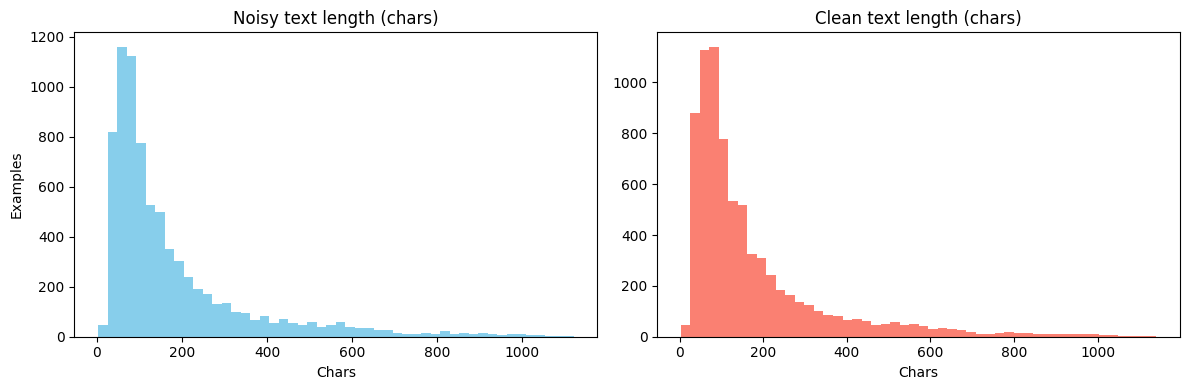

Random samples:
---
NOISY: Nakakainis talaga, pero wala na tayong magagawa. Grabe naman, nakakaloka na talaga. Ganyan talaga ang buhay natin dito eh. Ok, I just want a good discussion so here is an example…we will assume that your meme post about someone got thousands of upvotes, do you think it will change anything about our current situation, do you think the normies will browse reddit and be informed about your post Hindi ko na rin alam kung bakit ganyan pa rin. Di ko na rin alam kung paano pa ito aayusin.
CLEAN: Nakakainis talaga, pero wala na tayong magagawa. Grabe naman, nakakaloka na talaga. Ganyan talaga ang buhay natin dito eh. Okay, I just want a good discussion so here is an example…we will assume that your meme post about someone got thousands of upvotes, do you think it will change anything about our current situation, do you think the normies will browse reddit and be informed about your post Hindi ko na rin alam kung bakit ganyan pa rin. Di ko na rin alam kung paano pa i

In [67]:
# Length statistics
df_clean['noisy_len_chars'] = df_clean['noisy_text'].str.len()
df_clean['clean_len_chars'] = df_clean['clean_text'].str.len()
print(df_clean[['noisy_len_chars','clean_len_chars']].describe())

# Plot distributions
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(df_clean['noisy_len_chars'], bins=50, color='skyblue')
plt.title('Noisy text length (chars)')
plt.xlabel('Chars')
plt.ylabel('Examples')

plt.subplot(1,2,2)
plt.hist(df_clean['clean_len_chars'], bins=50, color='salmon')
plt.title('Clean text length (chars)')
plt.xlabel('Chars')
plt.tight_layout()
plt.show()

# Show random samples (beginner-friendly)
print('Random samples:')
for i, row in df_clean.sample(n=min(10, len(df_clean)), random_state=42).iterrows():
    print('---')
    print('NOISY:', row['noisy_text'])
    print('CLEAN:', row['clean_text'])

## Train / Validation / Test Split

Split proportions: train=90%, validation=5%, test=5% (deterministic with a fixed seed).

In [68]:
# Convert to train/val/test with sklearn for reproducibility
train_df, holdout = train_test_split(df_clean, train_size=0.9, random_state=config.SEED, shuffle=True)
val_df, test_df = train_test_split(holdout, test_size=0.5, random_state=config.SEED, shuffle=True)
print('Train:', len(train_df), 'Val:', len(val_df), 'Test:', len(test_df))

# Convert to Hugging Face Dataset objects for Trainer integration
train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
val_ds = Dataset.from_pandas(val_df.reset_index(drop=True))
test_ds = Dataset.from_pandas(test_df.reset_index(drop=True))
print('Datasets prepared.')

Train: 6838 Val: 380 Test: 380
Datasets prepared.


## Tokenization

We prefix inputs with `"fix grammar: "` and tokenize with `AutoTokenizer`. Max lengths are 128 for both input and target.

In [69]:
# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained(config.MODEL_NAME)
print('Tokenizer loaded.')

def preprocess_batch(examples):
    # Prepare inputs and targets
    inputs = [config.PREFIX + x for x in examples['noisy_text']]
    targets = examples['clean_text']
    # Tokenize inputs
    model_inputs = tokenizer(inputs, max_length=config.MAX_INPUT_LENGTH, truncation=True, padding=False)
    # Tokenize targets using the modern `text_target` argument
    labels = tokenizer(text_target=targets, max_length=config.MAX_TARGET_LENGTH, truncation=True, padding=False)
    model_inputs['labels'] = labels['input_ids']
    return model_inputs

# Tokenize datasets (batched to be faster)
tokenized_train = train_ds.map(preprocess_batch, batched=True, remove_columns=train_ds.column_names)
tokenized_val = val_ds.map(preprocess_batch, batched=True, remove_columns=val_ds.column_names)
tokenized_test = test_ds.map(preprocess_batch, batched=True, remove_columns=test_ds.column_names)
print('Tokenization complete.')

Tokenizer loaded.


Map:   0%|          | 0/6838 [00:00<?, ? examples/s]

Map:   0%|          | 0/380 [00:00<?, ? examples/s]

Map:   0%|          | 0/380 [00:00<?, ? examples/s]

Tokenization complete.


## Load mT5 Model

We use `AutoModelForSeq2SeqLM` from Hugging Face Transformers.

In [70]:
# Load model
model = AutoModelForSeq2SeqLM.from_pretrained(config.MODEL_NAME)
print('Model loaded.')
# Decide device and fp16 automatically
device = 'cuda' if torch.cuda.is_available() else 'cpu'
use_fp16 = torch.cuda.is_available()
print('Device:', device, 'fp16:', use_fp16)
model.to(device)

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Model loaded.
Device: cpu fp16: False


MT5ForConditionalGeneration(
  (shared): Embedding(250112, 512)
  (encoder): MT5Stack(
    (embed_tokens): Embedding(250112, 512)
    (block): ModuleList(
      (0): MT5Block(
        (layer): ModuleList(
          (0): MT5LayerSelfAttention(
            (SelfAttention): MT5Attention(
              (q): Linear(in_features=512, out_features=384, bias=False)
              (k): Linear(in_features=512, out_features=384, bias=False)
              (v): Linear(in_features=512, out_features=384, bias=False)
              (o): Linear(in_features=384, out_features=512, bias=False)
              (relative_attention_bias): Embedding(32, 6)
            )
            (layer_norm): MT5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): MT5LayerFF(
            (DenseReluDense): MT5DenseGatedActDense(
              (wi_0): Linear(in_features=512, out_features=1024, bias=False)
              (wi_1): Linear(in_features=512, out_features=1024, bias=False)
          

## Training Setup

Configure `Seq2SeqTrainingArguments`, `DataCollatorForSeq2Seq`, and a `Seq2SeqTrainer` with a `compute_metrics` function for BLEU and approximate accuracy.

In [71]:
# Data collator handles padding and label padding to -100
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model, label_pad_token_id=-100)

# Training arguments
training_args = Seq2SeqTrainingArguments(
    output_dir=config.CHECKPOINT_DIR,
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=config.LEARNING_RATE,
    per_device_train_batch_size=config.TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=config.EVAL_BATCH_SIZE,
    weight_decay=config.WEIGHT_DECAY,
    num_train_epochs=config.NUM_TRAIN_EPOCHS,
    logging_steps=100,
    save_total_limit=3,
    predict_with_generate=True,
    load_best_model_at_end=True,
    metric_for_best_model='bleu',
    fp16=use_fp16,
    seed=config.SEED,
)

# Compute metrics for evaluation
def postprocess_texts(preds, labels):
    preds = [p.strip() for p in preds]
    labels = [l.strip() for l in labels]
    return preds, labels

def compute_metrics(eval_pred):
    preds, labels = eval_pred
    if isinstance(preds, tuple):
        preds = preds[0]
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    # Replace -100 in the labels as tokenizer.pad_token_id for decoding
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    decoded_preds, decoded_labels = postprocess_texts(decoded_preds, decoded_labels)
    # BLEU via sacrebleu (expects list of hyps and list of list-of-refs)
    try:
        bleu = sacrebleu.corpus_bleu(decoded_preds, [decoded_labels]).score
    except Exception:
        bleu = 0.0
    # Approximate accuracy (conservative normalize)
    approx_acc = utils.compute_approx_accuracy(decoded_preds, decoded_labels)
    return {
        'bleu': round(float(bleu), 4),
        'approx_acc': round(float(approx_acc), 4),
    }

# Set seed for reproducibility
set_seed(config.SEED)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)
print('Trainer ready.')

Trainer ready.


## Model Training

Run training. This will show progress bars and save checkpoints to `./models/checkpoints`.

In [72]:
# Start training (this may take a long time on CPU)
train_result = trainer.train()
trainer.save_model(config.FINAL_MODEL_DIR)
tokenizer.save_pretrained(config.FINAL_MODEL_DIR)
print('Training completed. Final model saved to', config.FINAL_MODEL_DIR)

c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

## Training & Evaluation Loss Plots

Plot training and evaluation loss over time using the trainer's log history.

In [ ]:
# Extract loss history
log_history = trainer.state.log_history
train_steps = [x['step'] for x in log_history if 'loss' in x]
train_losses = [x['loss'] for x in log_history if 'loss' in x]
eval_steps = [x['step'] for x in log_history if 'eval_loss' in x]
eval_losses = [x['eval_loss'] for x in log_history if 'eval_loss' in x]

plt.figure(figsize=(8,4))
if train_steps:
    plt.plot(train_steps, train_losses, label='train_loss')
if eval_steps:
    plt.plot(eval_steps, eval_losses, label='eval_loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.legend()
plt.title('Training & Evaluation Loss')
plt.grid(True)
plt.tight_layout()
plot_path = os.path.join(config.OUTPUTS_DIR, 'loss_plot.png')
plt.savefig(plot_path)
print('Saved loss plot to', plot_path)
plt.show()

## Evaluation Metrics on Test Set

Compute BLEU and approximate accuracy on the test set and save metrics.

In [ ]:
# Predict on test set (uses generate internally because predict_with_generate=True)
predictions = trainer.predict(tokenized_test)
preds = predictions.predictions
labels = predictions.label_ids
# Decode predictions and labels
decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
decoded_preds, decoded_labels = postprocess_texts(decoded_preds, decoded_labels)
# BLEU
bleu = sacrebleu.corpus_bleu(decoded_preds, [decoded_labels]).score if len(decoded_preds) > 0 else 0.0
approx_acc = utils.compute_approx_accuracy(decoded_preds, decoded_labels)
metrics = {'bleu': float(bleu), 'approx_acc': float(approx_acc)}
print('Test BLEU:', metrics['bleu'])
print('Test approx accuracy:', metrics['approx_acc'])
# Save metrics
metrics_path = os.path.join(config.OUTPUTS_DIR, 'metrics.json')
utils.save_json(metrics, metrics_path)
print('Saved metrics to', metrics_path)

## Sample Predictions

Display at least 10 examples comparing input, prediction, and ground truth.

In [ ]:
# Prepare sample predictions
num_display = min(10, len(decoded_preds))
indices = list(range(num_display))
samples = []
for i in indices:
    inp = test_df.reset_index(drop=True).loc[i, 'noisy_text'] if i < len(test_df) else ''
    samples.append({
        'input': inp,
        'prediction': decoded_preds[i],
        'reference': decoded_labels[i]
    })
    print('INPUT:', inp)
    print('PREDICTION:', decoded_preds[i])
    print('GROUND TRUTH:', decoded_labels[i])
    print('---')

# Save samples to outputs
samples_path = os.path.join(config.OUTPUTS_DIR, 'samples.json')
utils.save_json(samples, samples_path)
print('Saved sample predictions to', samples_path)

## Save Final Model

Model and tokenizer were saved after training to `./models/final_model`. You can reload them with `AutoModelForSeq2SeqLM.from_pretrained(...)` and `AutoTokenizer.from_pretrained(...)`.

## Interactive Inference

Use the helper below to correct an input Taglish sentence. Change the `text` variable and run the cell.

In [ ]:
# Inference helper using utils.correct_text
def correct_text_interactive(text: str, num_beams: int = 4):
    return utils.correct_text(model, tokenizer, text, device=device, prefix=config.PREFIX,
                              max_input_length=config.MAX_INPUT_LENGTH, max_target_length=config.MAX_TARGET_LENGTH, num_beams=num_beams)

# Example usage (edit `text` and run this cell)
text = 'nageedit ako ng docs kahapon'
print('INPUT:', text)
print('PREDICTION:', correct_text_interactive(text))